$$
\begin{array}{c}
\textbf{Linear Regression - Spring 2026}\\\\
\textit{Center for Data Science, New York University} \\\\
\textit{February 20, 2026}\\\\\
\text{ Prepared by: Vivek Kumar Agarwal}\\\\
\textbf{Recitation 4: Linear Regression}
\end{array}
$$

![Linear Regression](../figures/LR_lab4_image1.png)

---

# Recitation 4: OLS & OLS Standard Errors

## Outline

### Part A — Ordinary Least Squares (OLS)
1. Setup & Deriving the OLS Estimators
2. OLS as Least Squares
3. Visualizing the Loss Surface
4. Properties of OLS
5. Simulating OLS: Consistency, Homo- vs. Heteroskedasticity

### Part B — OLS Standard Errors
6. Limiting Distribution & Statistical Inference
7. When to Cluster
8. Monte Carlo Simulations: Comparing Standard Errors (with P-value Histograms)

---

## Setup & Deriving the OLS Estimators

We've seen three interpretations of the linear regression model:

$$Y = \beta_0 + \beta_1 X + \varepsilon$$

Regardless of interpretation (descriptive, predictive, or causal), for estimation we require three conditions:

1. $E[\varepsilon] = 0$ — can always be assumed (it just pins down $\beta_0$)
2. $E[X\varepsilon] = 0$ — see below
3. $0 < \text{Var}(X) < \infty$ — trivial; just means $X$ has some (but not infinite) variation

**On condition 2:** Under a descriptive or predictive interpretation, recall that $\beta_1 = \text{Cov}(X,Y)/\text{Var}(X)$ is defined as the BLP slope. The error $\varepsilon = Y - \beta_0 - \beta_1 X$ is then *constructed* so that $E[X\varepsilon] = 0$ — it's baked into the definition. So this condition is automatically satisfied.

Under a causal interpretation, $\varepsilon$ represents all other causal determinants of $Y$ besides $X$. Now $E[X\varepsilon] = 0$ is a real, substantive assumption — it says $X$ is uncorrelated with those other determinants (exogeneity). This needs to be argued for and won't always hold.

**Bottom line:** We can *always* estimate a descriptively/predictively interpreted regression. Causal estimation is only sometimes possible.

---

### Deriving the Estimators

Starting from $E[\varepsilon] = 0$ and $\varepsilon = Y - \beta_0 - \beta_1 X$:

$$E[Y - \beta_0 - \beta_1 X] = 0 \implies \beta_0 = E[Y] - \beta_1 E[X]$$

Now plug this into $E[X\varepsilon] = 0$:

$$E[X(Y - \beta_0 - \beta_1 X)] = 0$$

$$E[X\big((Y - E[Y]) - \beta_1(X - E[X])\big)] = 0$$

$$\underbrace{E[X(Y - E[Y])]}_{= \text{Cov}(X,Y)} = \beta_1 \underbrace{E[X(X - E[X])]}_{= \text{Var}(X)}$$

So:

$$\beta_1 = \frac{\text{Cov}(X,Y)}{\text{Var}(X)}, \qquad \beta_0 = E[Y] - \beta_1 E[X]$$

Given an i.i.d. sample $(X_1, Y_1), \dots, (X_n, Y_n)$, we estimate these by replacing population quantities with sample analogs:

$$\hat{\beta}_1 = \frac{\hat{\sigma}_{X,Y}}{\hat{\sigma}^2_X}, \qquad \hat{\beta}_0 = \bar{Y}_n - \hat{\beta}_1 \bar{X}_n$$

where $\hat{\sigma}_{X,Y} = \frac{1}{n}\sum_{i=1}^n X_i Y_i - \bar{X}_n \bar{Y}_n$ is the sample covariance. These are the **Ordinary Least Squares (OLS)** estimators.

---

## OLS as Least Squares

The OLS estimators have a nice interpretation: they solve the sample analog of the BLP minimization problem.

The population regression parameters solve:

$$\min_{b_0, b_1} E\left[(Y - (b_0 + b_1 X))^2\right]$$

The OLS estimators solve the same problem *within the sample*:

$$\min_{b_0, b_1} \frac{1}{n} \sum_{i=1}^n (Y_i - (b_0 + b_1 X_i))^2$$

In other words, OLS finds the **line of best fit** — the line that minimizes the sum of squared residuals $\hat{\varepsilon}_i = Y_i - (\hat{\beta}_0 + \hat{\beta}_1 X_i)$. Hence the name *Ordinary Least Squares*.

An important implication: the OLS residuals satisfy

$$\frac{1}{n}\sum_{i=1}^n \hat{\varepsilon}_i = 0, \qquad \frac{1}{n}\sum_{i=1}^n X_i \hat{\varepsilon}_i = 0$$

The residuals sum to zero and are uncorrelated with $X$ in the sample — this is the **geometric interpretation** of OLS.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm

np.random.seed(42)

# Generate data from a known DGP: Y = 2 + 3X + ε
n = 100
X = np.random.normal(5, 1, n)
eps = np.random.normal(0, 1, n)
Y = 2 + 3 * X + eps

# OLS estimate for reference
X_with_const = sm.add_constant(X)
ols = sm.OLS(Y, X_with_const).fit()
b0_hat, b1_hat = ols.params
print(f"True: β₀ = 2, β₁ = 3")
print(f"OLS:  β̂₀ = {b0_hat:.3f}, β̂₁ = {b1_hat:.3f}")

True: β₀ = 2, β₁ = 3
OLS:  β̂₀ = 2.724, β̂₁ = 2.857


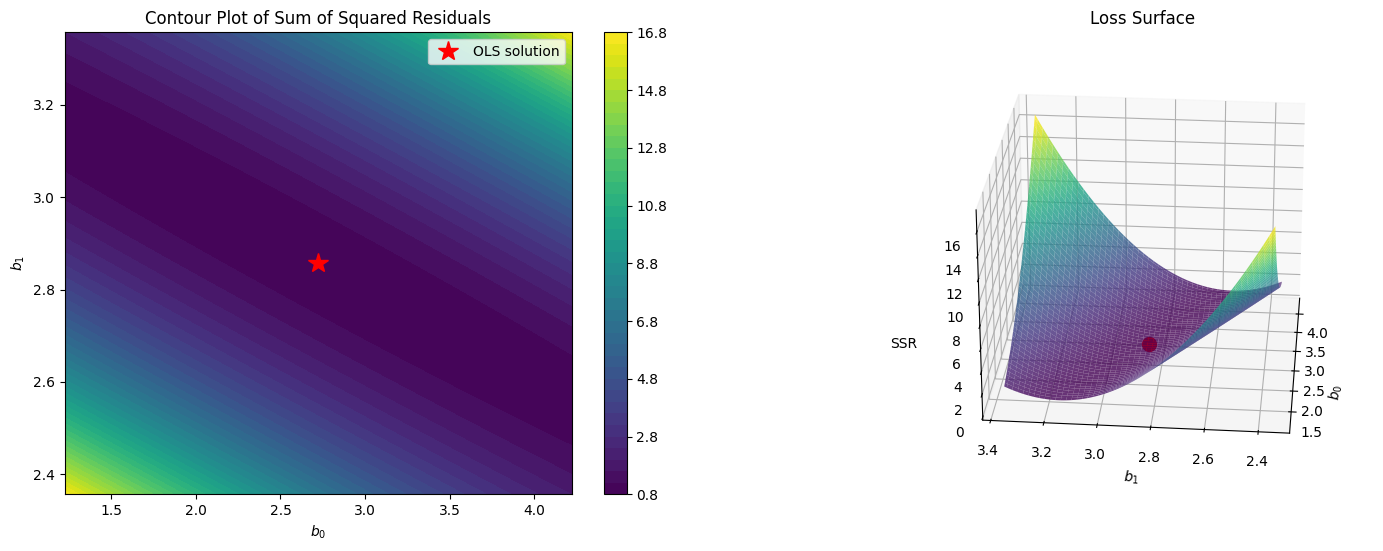

In [10]:
# Define the sum of squared residuals as a function of (b0, b1)
def ssr(b0, b1, X, Y):
    return np.sum((Y - (b0 + b1 * X))**2) / len(X)

# Tighter grid centered on the OLS solution
b0_grid = np.linspace(b0_hat - 1.5, b0_hat + 1.5, 100)
b1_grid = np.linspace(b1_hat - 0.5, b1_hat + 0.5, 100)
B0, B1 = np.meshgrid(b0_grid, b1_grid)
Z = np.array([[ssr(b0, b1, X, Y) for b0 in b0_grid] for b1 in b1_grid])

fig = plt.figure(figsize=(18, 6))

# Contour plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(B0, B1, Z, levels=40, cmap='viridis')
ax1.plot(b0_hat, b1_hat, 'r*', markersize=15, label='OLS solution')
ax1.set_xlabel('$b_0$')
ax1.set_ylabel('$b_1$')
ax1.set_title('Contour Plot of Sum of Squared Residuals')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D surface
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.plot_surface(B0, B1, Z, cmap='viridis', alpha=0.8)
ax3d.scatter(b0_hat, b1_hat, ssr(b0_hat, b1_hat, X, Y), color='red', s=100, zorder=5)
ax3d.set_xlabel('$b_0$')
ax3d.set_ylabel('$b_1$')
ax3d.set_zlabel('SSR', labelpad=15)
ax3d.set_title('Loss Surface')
ax3d.view_init(elev=25, azim=185)

plt.savefig('loss_surface.png', bbox_inches='tight', dpi=100)
plt.show()

### Interpreting the Loss Surface

We define the **SSR (Sum of Squared Residuals)** as:

$$\text{SSR}(b_0, b_1) = \frac{1}{n}\sum_{i=1}^n (Y_i - b_0 - b_1 X_i)^2$$

This measures how badly a particular line (defined by $b_0, b_1$) fits the data.

**Left — Contour Plot:**
The x-axis is $b_0$ (intercept) and the y-axis is $b_1$ (slope) — these represent all the *possible* values we could pick for our regression line. The colored regions are **level curves**: each band connects all $(b_0, b_1)$ pairs that produce the same SSR. The color indicates the SSR value — darker/purple means lower (better fit), brighter/yellow means higher (worse fit). The red star marks the OLS solution $(\hat{\beta}_0, \hat{\beta}_1)$, which sits in the darkest region — the combination of intercept and slope that gives us the smallest possible SSR.

**Right — 3D Surface:**
Same information but now the SSR is shown on the vertical axis (z-axis). The horizontal axes are again $b_0$ and $b_1$. The surface forms a **bowl shape** — as we move away from the OLS solution in any direction, the SSR increases. The red dot at the bottom of the bowl is the OLS solution. This is what "least squares" means geometrically: OLS picks the single point at the bottom of this bowl.

**Takeaway:** There are infinitely many lines we *could* draw through the data (each corresponding to a different $(b_0, b_1)$ pair), but OLS finds the one that minimizes the SSR — the unique bottom of the bowl.

---

## Properties of OLS

### Consistency

Under pretty minimal assumptions, OLS is **consistent**:

$$\hat{\beta}_1 = \frac{\hat{\sigma}_{X,Y}}{\hat{\sigma}^2_X} \xrightarrow{p} \frac{\text{Cov}(X,Y)}{\text{Var}(X)} = \beta_1$$

This follows from the WLLN (sample covariance and variance converge to their population counterparts) and the CMT (their ratio converges too, since $\text{Var}(X) > 0$). Consistency of $\hat{\beta}_0$ follows almost immediately.

**What do we need?** Just:
- The maintained assumptions ($E[\varepsilon]=0$, $E[X\varepsilon]=0$, $0 < \text{Var}(X) < \infty$)
- An i.i.d. sample

That's it. For large samples, OLS will be close to the truth — and we can always interpret descriptively.

---

### Unbiasedness

Recall that an estimator is **unbiased** if, on average across all possible samples we could have drawn, it equals the true parameter: $E[\hat{\beta}_1] = \beta_1$. Any single sample might give us an estimate that's too high or too low, but unbiasedness means there's no *systematic* tendency to err in one direction.

Is OLS unbiased? **Not always.** It depends on whether $E[Y|X]$ is linear in $X$.

**Why?** OLS is constrained to fit a straight line. If the true conditional expectation $E[Y|X]$ is curved, then a straight line will systematically miss the curve — sometimes overshooting, sometimes undershooting, but *not* in a way that cancels out on average. That systematic miss is bias.

If $E[Y|X]$ is already a straight line, there's no such mismatch — OLS is fitting the right shape, and across repeated samples the estimates will center on the truth.

**When is $E[Y|X]$ linear?**
- When the underlying relationship is genuinely linear (e.g. birthday cake candles vs. age)
- When $X$ is **binary** — two points always lie on a line, so $E[Y|X]$ is automatically linear. This is why regression works so cleanly for experiments with treatment/control.
- Sometimes we can *make* it linear by redefining $X$ — e.g. $E[\text{Bike rentals}|\text{Temp}]$ is curved, but $E[\text{Bike rentals}|\text{Temp}^2]$ might be approximately linear

**If $E[Y|X]$ is non-linear, should we worry?** Not too much — remember OLS is still **consistent**. Bias is a finite-sample problem. As $n$ grows large, consistency kicks in and the estimate converges to the true value regardless.

### Homo- vs. Heteroskedasticity

So far: OLS is consistent (always) and unbiased (when $E[Y|X]$ is linear). What about variance? This depends on how the residuals behave.

The residual $\varepsilon$ captures everything about $Y$ that our regression line *doesn't* explain. The question is: does the amount of "unexplained stuff" stay the same across all values of $X$, or does it change?

- **Homoskedastic** ("same spread"): no matter what value $X$ takes, the residuals have the same variance. If you looked at the scatter plot, the cloud of points would be equally thick above and below the line everywhere.

- **Heteroskedastic** ("different spread"): the variance of the residuals changes with $X$. The scatter is tight in some regions and wide in others.

**Example — Height vs. Age:** At age 0, almost all babies are roughly the same height — if we predict height using age, we won't be off by much. At age 18, some people are 5'2" and others are 6'4" — our prediction errors are much larger. The "unexplained spread" *grows* with age. That's heteroskedasticity.

**Example — Height at 18 vs. Year of Birth:** Average height has increased over generations, but within any generation, the spread of heights is roughly the same. Whether you were born in 1960 or 2000, there's a similar mix of shorter and taller people. That's homoskedasticity.

We'll see this visually in a moment. It matters because:

### Gauss-Markov Theorem (BLUE)

Under linearity + i.i.d. + **homoskedasticity**, OLS has the **smallest variance** of any unbiased estimator. This is the Gauss-Markov Theorem — OLS is **BLUE** (Best Linear Unbiased Estimator).

This requires a lot of conditions. In practice, **consistency** is the most reliable reason to use OLS — it holds under much weaker assumptions. The rest are bonuses.

---

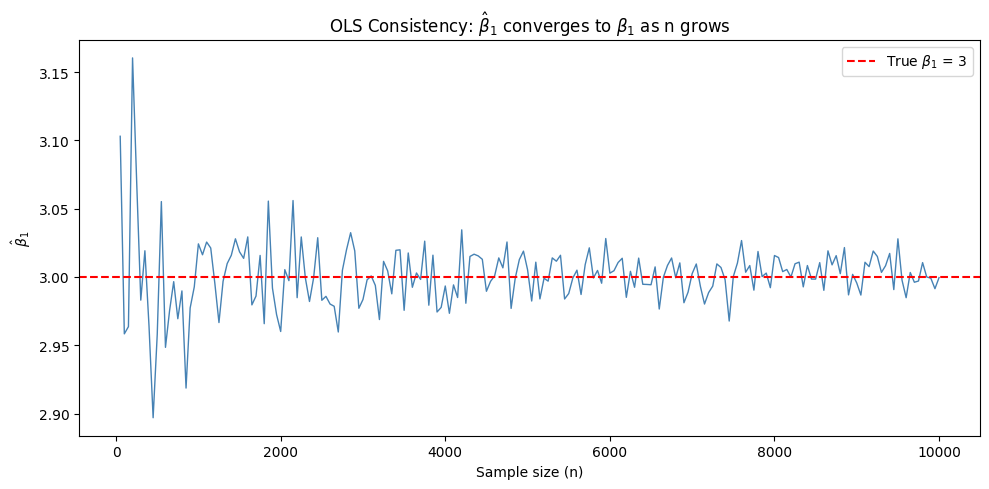

In [12]:
# Simulate OLS consistency: β̂₁ should converge to true β₁ as n grows

true_b0 = 2
true_b1 = 3
sample_sizes = np.arange(50, 10001, 50)
b1_estimates = []

np.random.seed(42)

for n in sample_sizes:
    X_sim = np.random.normal(5, 1, n)
    eps_sim = np.random.normal(0, 1, n)
    Y_sim = true_b0 + true_b1 * X_sim + eps_sim
    
    X_with_const = sm.add_constant(X_sim)
    b1_hat_sim = sm.OLS(Y_sim, X_with_const).fit().params[1]
    b1_estimates.append(b1_hat_sim)

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, b1_estimates, color='steelblue', linewidth=1)
plt.axhline(y=true_b1, color='red', linestyle='--', label=f'True $\\beta_1$ = {true_b1}')
plt.xlabel('Sample size (n)')
plt.ylabel('$\\hat{\\beta}_1$')
plt.title('OLS Consistency: $\\hat{\\beta}_1$ converges to $\\beta_1$ as n grows')
plt.legend()
plt.tight_layout()
plt.show()

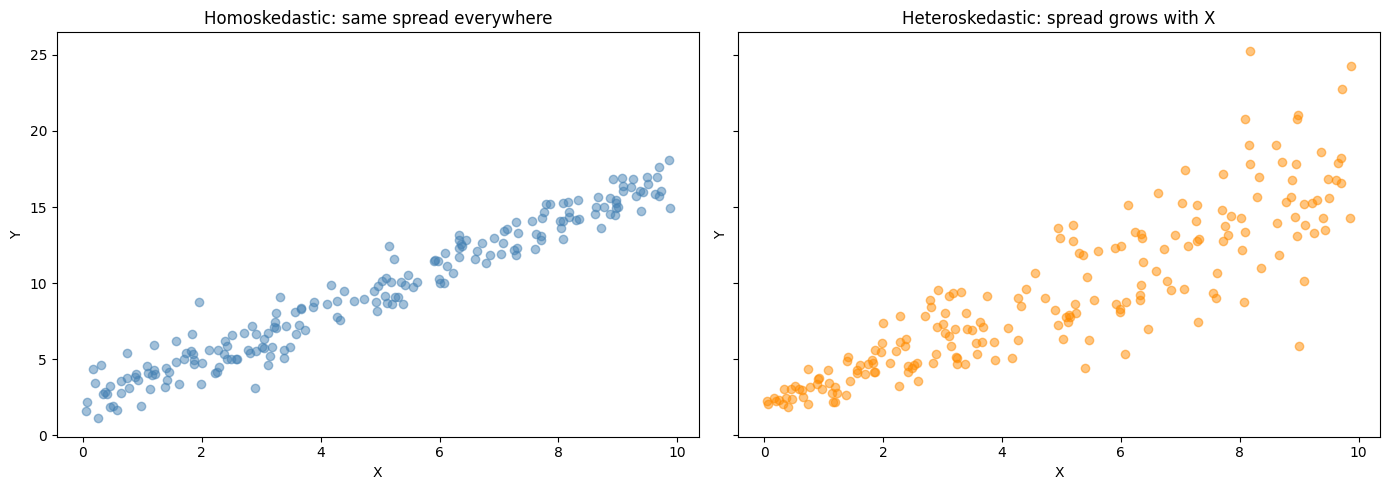

In [13]:
np.random.seed(42)
n = 200

X_sim = np.random.uniform(0, 10, n)

# Homoskedastic: constant spread
Y_homo = 2 + 1.5 * X_sim + np.random.normal(0, 1, n)

# Heteroskedastic: spread grows with X
Y_hetero = 2 + 1.5 * X_sim + np.random.normal(0, 1, n) * (0.3 + 0.4 * X_sim)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Homoskedastic plot
axes[0].scatter(X_sim, Y_homo, alpha=0.5, color='steelblue')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('Homoskedastic: same spread everywhere')

# Heteroskedastic plot
axes[1].scatter(X_sim, Y_hetero, alpha=0.5, color='darkorange')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_title('Heteroskedastic: spread grows with X')

plt.tight_layout()
plt.show()

---

---

---

## Part B — OLS Standard Errors

## Limiting Distribution & Statistical Inference

For any finite sample, our OLS estimate $\hat{\beta}_1$ will be "off" by some amount — there's always sampling error. The question is: **how much stock should we put in our estimate?**

The answer comes from the **limiting distribution** of OLS. For large $n$:

$$\frac{\hat{\beta}_1 - \beta_1}{\widehat{SE}} \;\approx\; N(0, 1)$$

What does this say? The "error" in our estimate $(\hat{\beta}_1 - \beta_1)$, once we scale it by the **standard error** $\widehat{SE}$, behaves approximately like a standard normal random variable.

Think of it this way: we don't know $\beta_1$, and every sample gives us a slightly different $\hat{\beta}_1$. The limiting distribution tells us the *shape* of that randomness — it's approximately bell-curved. If we can pin down the standard error, we can make **probabilistic statements** about how far off we might be.

Two common ways to use this:
- **Hypothesis testing**: is a particular value of $\beta_1$ plausible given our data?
- **Confidence intervals**: what *range* of values is plausible?

---

### Hypothesis Testing

Suppose we want to argue that $X$ has a non-zero linear relationship with $Y$. We set up:

- **Null hypothesis** $H_0: \beta_1 = 0$ — the claim we're trying to disprove
- **Alternative hypothesis** $H_1: \beta_1 \neq 0$ — what we're trying to argue for

Under $H_0$, the limiting distribution simplifies to:

$$\frac{\hat{\beta}_1}{\widehat{SE}} \;\approx\; N(0,1)$$

So *if* $H_0$ is true, $\hat{\beta}_1 / \widehat{SE}$ should look like a draw from a standard normal — probably somewhere between -2 and 2.

We compute a **p-value**: the probability of seeing a result as or more extreme than ours, *if the null were true*. A small p-value means our data would be very surprising under $H_0$ — evidence against it. If the p-value falls below a pre-specified **significance level** (commonly 0.05), we **reject the null**.

**Example:** p-value of 0.02 at a 0.05 significance level → reject. There's less than a 5% chance we'd see a sample this extreme if $\beta_1$ were truly zero.

---

### Confidence Intervals

Instead of testing a single value, we can ask: **what range of values for $\beta_1$ is plausible given our data?**

A **95% confidence interval** is the set of all values of $\beta_1$ that we would *not* reject at the 0.05 significance level. It has a 95% probability of containing the true $\beta_1$.

Using the limiting distribution, a 95% CI takes the form:

$$\hat{\beta}_1 \pm 1.96 \times \widehat{SE}$$

The logic: any value within $\pm 1.96$ standard errors of our estimate is "close enough" that we can't distinguish it from our data — so we can't reject it.

**Key point for both hypothesis tests and CIs:** everything depends on having a good estimate of the standard error $\widehat{SE}$. If our standard error is wrong, our p-values and confidence intervals will be wrong too. This is what Part B is really about — *when* can we trust different standard errors?

---

## When to Cluster

To compute standard errors, we need to know something about the structure of our data. So far we've assumed i.i.d. sampling — but what if observations are **correlated within groups**?

This is called **clustering**: both the $X$'s and the $\varepsilon$'s are correlated *within* groups in the data. Three common situations:

**1. $X$ is assigned to groups:** Suppose we regress employee productivity on whether a company has a remote work policy. Every employee at the same company has the *exact same* policy (correlated $X$'s), and employees at the same company share similar culture, tools, and management (correlated $\varepsilon$'s). The cluster here is the company.

**2. Sampling whole groups:** Suppose we want to study income across the US population, but instead of sampling individuals at random, we randomly select *households* and survey everyone in them. Members of the same household share similar backgrounds, neighborhoods, and resources — correlated $X$'s and $\varepsilon$'s. The cluster here is the household.

**3. Panel data:** Suppose we track the same group of college students and measure their GPA every semester for four years. Each student has persistent traits — motivation, ability, study habits — that don't change much over time, creating correlation within an individual across semesters. The cluster here is the individual.

In all three cases, ignoring the clustering and using standard i.i.d.-based standard errors can give us **badly misleading inference** — as we'll see next.

## 8. Monte Carlo Simulations: Comparing Standard Errors

Here's the idea: we'll create a DGP where we **know** the truth — $\beta_1 = 0$ (no relationship between $X$ and $Y$). Then we'll pretend to be 10,000 different researchers, each drawing their own sample and running OLS.

Since $\beta_1 = 0$ is true, every rejection of $H_0: \beta_1 = 0$ is a **false rejection**. At a 0.05 significance level, this should happen about 5% of the time — that's what the significance level promises.

But here's the catch: that promise only holds if our **standard errors are correct**. If they're wrong, we might falsely reject far more often — meaning we'd be "finding" relationships that don't exist.

We'll test this by comparing different types of standard errors on clustered data, and visualize the results using **p-value histograms**:
- If SEs are correct → p-values spread out **uniformly** (flat histogram)
- If SEs are wrong → p-values pile up near **zero** (we reject way too often)

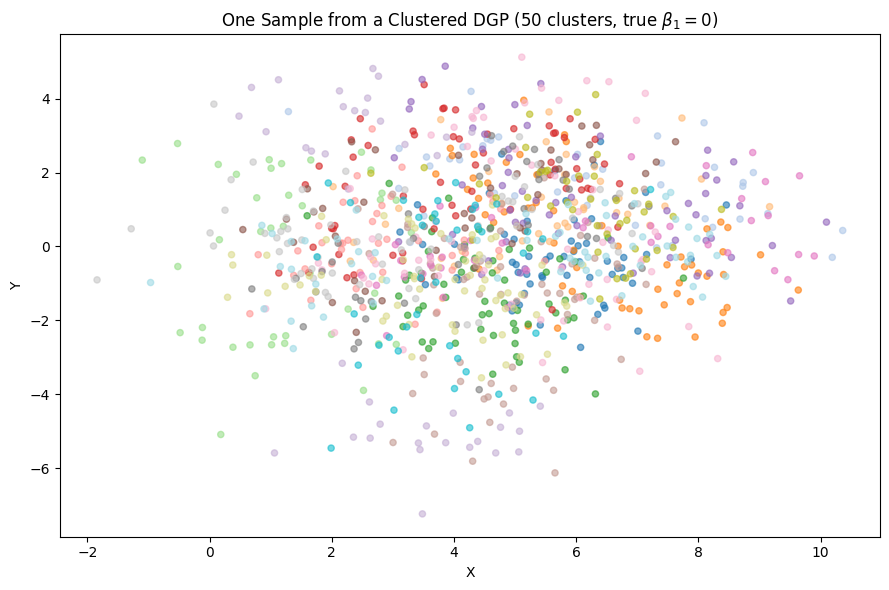

In [16]:
np.random.seed(42)

n_clusters = 50
n_per_cluster = 20  # total n = 1000

# Cluster-specific shifts
gamma = np.random.normal(0, 2, n_clusters)  # shifts X
psi = np.random.normal(0, 2, n_clusters)    # shifts Y

# Generate data
X_clust, Y_clust, cluster_id = [], [], []

for j in range(n_clusters):
    X_j = gamma[j] + np.random.normal(5, 1, n_per_cluster)
    Y_j = psi[j] + np.random.normal(0, 1, n_per_cluster)
    X_clust.extend(X_j)
    Y_clust.extend(Y_j)
    cluster_id.extend([j] * n_per_cluster)

X_clust = np.array(X_clust)
Y_clust = np.array(Y_clust)
cluster_id = np.array(cluster_id)

# Plot one sample, colored by cluster
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_clust, Y_clust, c=cluster_id, cmap='tab20', alpha=0.6, s=20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('One Sample from a Clustered DGP (50 clusters, true $\\beta_1 = 0$)')
plt.tight_layout()
plt.show()

In [17]:
np.random.seed(42)

n_sims = 10000
n_clusters = 50
n_per_cluster = 20

pvals_robust = []
pvals_clustered = []

for _ in range(n_sims):
    # Cluster-specific shifts
    gamma = np.random.normal(0, 2, n_clusters)
    psi = np.random.normal(0, 2, n_clusters)
    
    X_sim, Y_sim, clust_sim = [], [], []
    
    for j in range(n_clusters):
        X_j = gamma[j] + np.random.normal(5, 1, n_per_cluster)
        Y_j = psi[j] + np.random.normal(0, 1, n_per_cluster)
        X_sim.extend(X_j)
        Y_sim.extend(Y_j)
        clust_sim.extend([j] * n_per_cluster)
    
    X_sim = np.array(X_sim)
    Y_sim = np.array(Y_sim)
    clust_sim = np.array(clust_sim)
    
    X_with_const = sm.add_constant(X_sim)
    
    # Robust SEs (ignoring clustering)
    result_robust = sm.OLS(Y_sim, X_with_const).fit(cov_type='HC1')
    pvals_robust.append(result_robust.pvalues[1])
    
    # Clustered SEs
    result_clustered = sm.OLS(Y_sim, X_with_const).fit(cov_type='cluster', cov_kwds={'groups': clust_sim})
    pvals_clustered.append(result_clustered.pvalues[1])

pvals_robust = np.array(pvals_robust)
pvals_clustered = np.array(pvals_clustered)

print(f"False rejection rate — Robust SEs:    {np.mean(pvals_robust < 0.05):.1%}")
print(f"False rejection rate — Clustered SEs:  {np.mean(pvals_clustered < 0.05):.1%}")

False rejection rate — Robust SEs:    60.2%
False rejection rate — Clustered SEs:  7.4%


**Note** : In our simulation, we created the clusters ourselves so we know exactly what they are. In practice, **you** decide what to cluster on based on your understanding of the data 

- for example: "within what group are my observations likely to be correlated?" 
- If you're studying employees across companies and the policy varies at the company level, cluster by company. 
- If you sampled entire households, cluster by household. 
- If you observe the same people over time, cluster by individual. 
- The cluster variable is typically a column in your dataset (e.g. company ID, household ID, person ID).

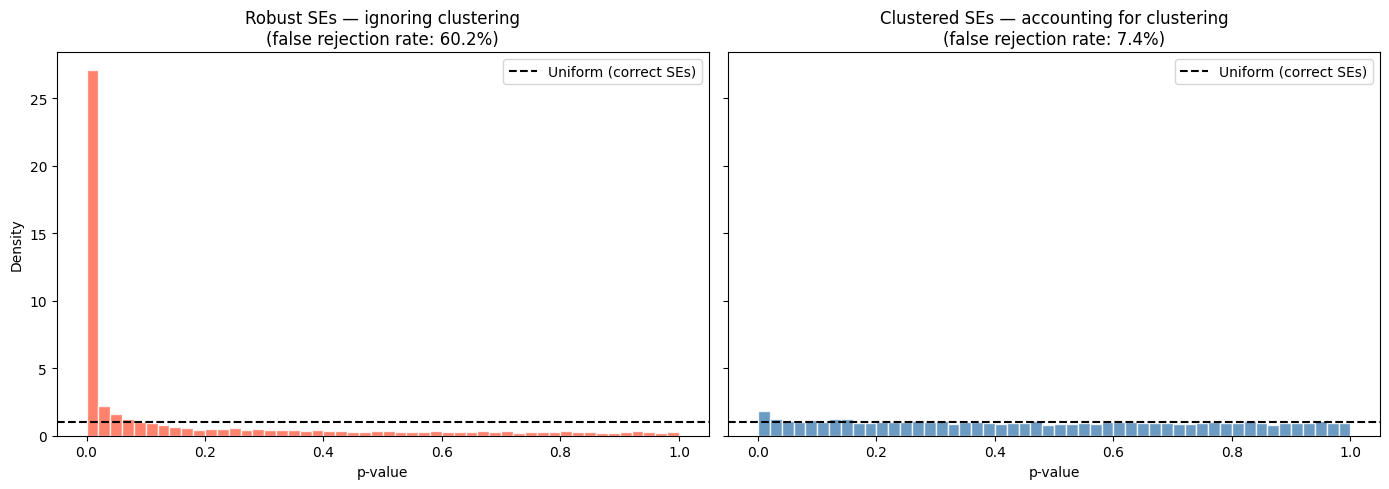

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Robust SEs
axes[0].hist(pvals_robust, bins=50, density=True, color='tomato', edgecolor='white', alpha=0.8)
axes[0].axhline(y=1, color='black', linestyle='--', label='Uniform (correct SEs)')
axes[0].set_xlabel('p-value')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Robust SEs — ignoring clustering\n(false rejection rate: {np.mean(pvals_robust < 0.05):.1%})')
axes[0].legend()

# Clustered SEs
axes[1].hist(pvals_clustered, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axhline(y=1, color='black', linestyle='--', label='Uniform (correct SEs)')
axes[1].set_xlabel('p-value')
axes[1].set_title(f'Clustered SEs — accounting for clustering\n(false rejection rate: {np.mean(pvals_clustered < 0.05):.1%})')
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpreting the P-value Histograms

Remember: the true $\beta_1 = 0$ in our DGP, so every rejection is a mistake. At a 0.05 significance level, we should only make this mistake about 5% of the time.

**Left plot (Robust SEs — ignoring clustering):** The p-values are overwhelmingly concentrated near 0. The false rejection rate is ~60% — over 12 times what it should be. 

What does this mean in practice? Imagine 100 researchers each studying whether remote work policies affect employee productivity, collecting data from employees across different companies. If they all use robust SEs (ignoring that employees within the same company are correlated), about 60 of them would publish a paper claiming remote work affects productivity — even if it truly doesn't. That's a flood of false findings.

**Right plot (Clustered SEs):** The p-values spread roughly uniformly — they sit flat along the dashed line. The false rejection rate is ~7%, close to the target of 5%. By clustering at the company level, the SEs become larger (more honest), because they recognize that 20 employees at the same company don't give you as much information as 20 employees at 20 different companies.

**The lesson:** With clustered data, using the wrong standard errors doesn't give you slightly off results — it can make you "discover" effects that don't exist the majority of the time.

---

### What if we have few clusters?

Clustered SEs worked well with 50 clusters. But what happens when we only have a handful — say 3?

Intuitively, clustered SEs treat clusters the way regular SEs treat individuals. Just like you need a large number of individual observations for standard inference to work, you need a **large number of clusters** for clustered inference to work. With only 3 clusters, it's like trying to estimate a population mean from 3 data points — not enough information.

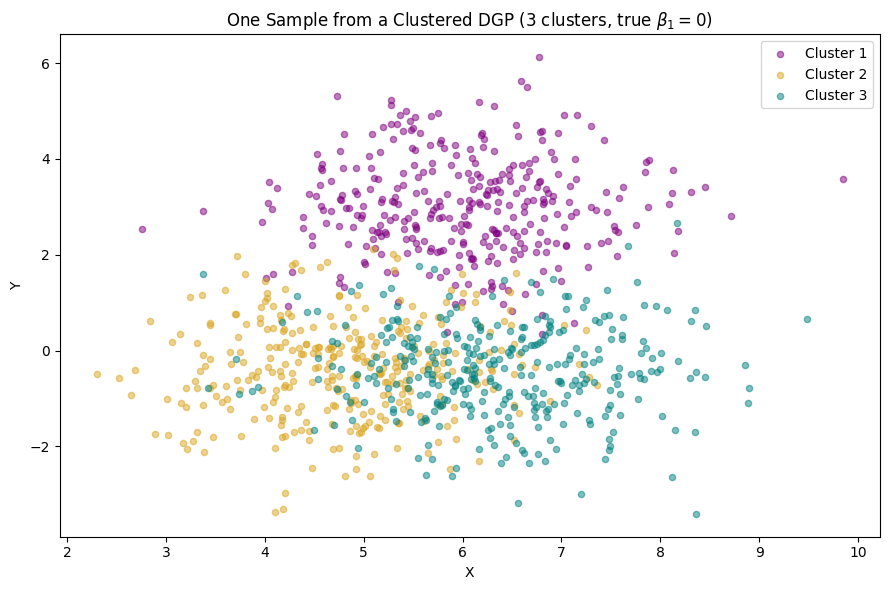

In [22]:
np.random.seed(42)

n_clusters_few = 3
n_per_cluster_few = 333

gamma_few = np.random.normal(0, 2, n_clusters_few)
psi_few = np.random.normal(0, 2, n_clusters_few)

X_few, Y_few, clust_few = [], [], []

for j in range(n_clusters_few):
    X_j = gamma_few[j] + np.random.normal(5, 1, n_per_cluster_few)
    Y_j = psi_few[j] + np.random.normal(0, 1, n_per_cluster_few)
    X_few.extend(X_j)
    Y_few.extend(Y_j)
    clust_few.extend([j] * n_per_cluster_few)

X_few = np.array(X_few)
Y_few = np.array(Y_few)
clust_few = np.array(clust_few)

plt.figure(figsize=(9, 6))
colors = ['purple', 'goldenrod', 'teal']
for j in range(n_clusters_few):
    mask = clust_few == j
    plt.scatter(X_few[mask], Y_few[mask], c=colors[j], alpha=0.5, s=20, label=f'Cluster {j+1}')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('One Sample from a Clustered DGP (3 clusters, true $\\beta_1 = 0$)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
np.random.seed(42)

n_sims = 10000

pvals_robust_few = []
pvals_clustered_few = []

for _ in range(n_sims):
    gamma = np.random.normal(0, 2, n_clusters_few)
    psi = np.random.normal(0, 2, n_clusters_few)
    
    X_sim, Y_sim, clust_sim = [], [], []
    
    for j in range(n_clusters_few):
        X_j = gamma[j] + np.random.normal(5, 1, n_per_cluster_few)
        Y_j = psi[j] + np.random.normal(0, 1, n_per_cluster_few)
        X_sim.extend(X_j)
        Y_sim.extend(Y_j)
        clust_sim.extend([j] * n_per_cluster_few)
    
    X_sim = np.array(X_sim)
    Y_sim = np.array(Y_sim)
    clust_sim = np.array(clust_sim)
    
    X_with_const = sm.add_constant(X_sim)
    
    # Robust SEs (ignoring clustering)
    result_robust = sm.OLS(Y_sim, X_with_const).fit(cov_type='HC1')
    pvals_robust_few.append(result_robust.pvalues[1])
    
    # Clustered SEs
    result_clustered = sm.OLS(Y_sim, X_with_const).fit(cov_type='cluster', cov_kwds={'groups': clust_sim})
    pvals_clustered_few.append(result_clustered.pvalues[1])

pvals_robust_few = np.array(pvals_robust_few)
pvals_clustered_few = np.array(pvals_clustered_few)

print(f"False rejection rate — Robust SEs:    {np.mean(pvals_robust_few < 0.05):.1%}")
print(f"False rejection rate — Clustered SEs:  {np.mean(pvals_clustered_few < 0.05):.1%}")

False rejection rate — Robust SEs:    91.6%
False rejection rate — Clustered SEs:  45.3%


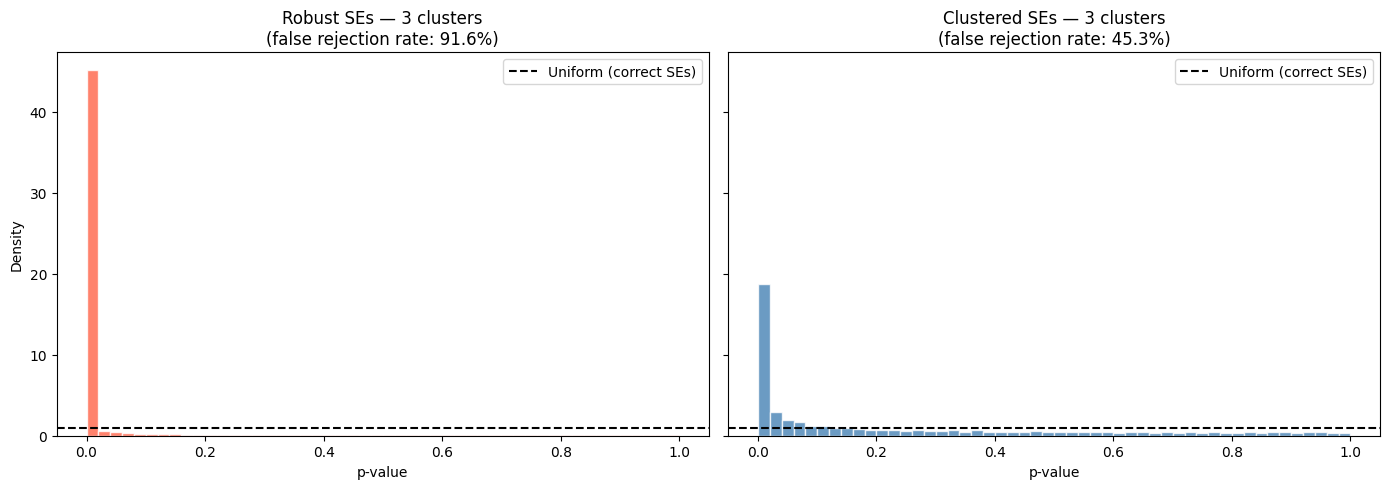

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Robust SEs
axes[0].hist(pvals_robust_few, bins=50, density=True, color='tomato', edgecolor='white', alpha=0.8)
axes[0].axhline(y=1, color='black', linestyle='--', label='Uniform (correct SEs)')
axes[0].set_xlabel('p-value')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Robust SEs — 3 clusters\n(false rejection rate: {np.mean(pvals_robust_few < 0.05):.1%})')
axes[0].legend()

# Clustered SEs
axes[1].hist(pvals_clustered_few, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axhline(y=1, color='black', linestyle='--', label='Uniform (correct SEs)')
axes[1].set_xlabel('p-value')
axes[1].set_title(f'Clustered SEs — 3 clusters\n(false rejection rate: {np.mean(pvals_clustered_few < 0.05):.1%})')
axes[1].legend()

plt.tight_layout()
plt.show()

### Few Clusters: Interpretation

With only 3 clusters, **both** types of standard errors fail:
- Robust SEs are still terrible (~91% false rejection) — same problem as before, they ignore clustering entirely
- Clustered SEs also struggle (~45% false rejection) — they *try* to account for clustering, but with only 3 clusters there simply isn't enough information to estimate the within-cluster correlation reliably


**Rule of thumb:** Clustered SEs need a large number of clusters (common guidelines suggest at least 30-50). 

---

## Key Takeaways

**Part A — OLS:**
- OLS estimates $\hat{\beta}_1 = \hat{\sigma}_{X,Y} / \hat{\sigma}^2_X$ — it finds the line that minimizes the sum of squared residuals
- **Consistency** holds under minimal assumptions (i.i.d. + maintained conditions) — the most reliable property
- **Unbiasedness** requires $E[Y|X]$ to be linear (guaranteed for binary $X$)
- **Minimum variance (BLUE)** requires linearity + i.i.d. + homoskedasticity (Gauss-Markov) — a fragile result

**Part B — Standard Errors:**
- Standard errors determine the quality of our inference (hypothesis tests, confidence intervals). Wrong SEs → wrong conclusions.
- **Default SEs** assume i.i.d. + homoskedasticity — fine when both hold, but rarely the best choice
- **Robust SEs** allow heteroskedasticity — a safe default when data is i.i.d.
- **Clustered SEs** allow within-group correlation — essential when data has a group structure, but require many clusters (30-50+)
- When in doubt about homoskedasticity, use robust SEs. If there's a group structure, cluster.
- If you have very few clusters, standard clustered SEs won't save you. Some possible approaches:
    - **Wild cluster bootstrap:** a resampling method designed specifically for few-cluster settings
    - **Aggregate to the cluster level:** collapse the data to cluster-level averages and run OLS on those — now each observation is independent
    - **Collect more clusters:** if possible, expand the sample to include more groups rather than more observations within existing groups

---

## Anyone without a group STILL? 


## Office Hours Friday 11 AM - 1 PM  Room No - 244
or dropin your questions at vka244@nyu.edu

---

---